# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [72]:
import pandas as pd

credit = pd.read_csv("credit score.txt")
credit.head(20)
# credit score.txt는 실제 학습 데이터가 아니라 컬럼 설명 파일이므로 참고용으로만 확인하였다.

,ID : 각 항목에 대한 고유 식별자
0,Customer_ID : 개인을 식별하는 고유 식별자
1,Month : 해당 연도의 월
2,Name : 개인의 이름
3,Age : 개인의 나이
4,SSN : 개인의 사회 보장 번호 (Social Security Number)
5,Occupation : 개인의 직업
6,Annual_Income : 개인의 연간 소득
7,Monthly_Inhand_Salary : 개인의 월별 기본 급여
8,Num_Bank_Accounts : 개인이 보유한 은행 계좌의 수
9,Num_Credit_Card : 개인이 보유한 신용카드의 수


In [73]:
train = pd.read_csv("train2.csv")
train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,268,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [74]:
train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [75]:
train.isnull().sum().sum()

#전체 결측치 개수 확인

np.int64(0)

In [76]:
train.info()

# EDA 결과 train2 데이터는 100000행, 28개 컬럼으로 구성되어 있으며 결측치는 존재하지 않았다.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  ob

In [77]:
train['Credit_Score'].value_counts()


,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


In [78]:
#범주형

categorical_cols = train.select_dtypes(include='object').columns
categorical_cols


Index(['Name', 'Occupation', 'Type_of_Loan', 'Credit_Mix',
       'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score'],
      dtype='object')

In [79]:
train[categorical_cols].nunique().sort_values(ascending=False)


,0
Name,10128
Type_of_Loan,6261
Occupation,15
Payment_Behaviour,6
Credit_Mix,3
Payment_of_Min_Amount,3
Credit_Score,3


In [80]:
for col in categorical_cols:
    print(f"\n[{col}]")
    print(train[col].value_counts().head(10))



[Name]
Name
Stevex                48
Langep                48
Jessicad              48
Nicko                 40
Johnc                 40
Jessica Wohlt         40
Deepa Seetharamanm    40
Nate Raymondw         40
Raymondr              40
Vaughanl              40
Name: count, dtype: int64

[Occupation]
Occupation
Lawyer           7096
Engineer         6864
Architect        6824
Mechanic         6776
Accountant       6744
Scientist        6744
Media_Manager    6720
Developer        6720
Teacher          6672
Entrepreneur     6648
Name: count, dtype: int64

[Type_of_Loan]
Type_of_Loan
No Data                    11408
not specified               1408
credit-builder loan         1280
personal loan               1272
debt consolidation loan     1264
student loan                1240
payday loan                 1200
mortgage loan               1176
auto loan                   1152
home equity loan            1136
Name: count, dtype: int64

[Credit_Mix]
Credit_Mix
Standard    45848
Good        

In [81]:
numeric_cols = train.select_dtypes(exclude='object').columns
numeric_cols


Index(['ID', 'Customer_ID', 'Month', 'Age', 'SSN', 'Annual_Income',
       'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance'],
      dtype='object')

In [82]:
train[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
ID,100000.0,8.063150e+04,4.330149e+04,5634.000000,4.313275e+04,8.063150e+04,1.181302e+05,1.556290e+05
Customer_ID,100000.0,2.598267e+04,1.434054e+04,1006.000000,1.366450e+04,2.577700e+04,3.838500e+04,5.099900e+04
Month,100000.0,4.500000e+00,2.291299e+00,1.000000,2.750000e+00,4.500000e+00,6.250000e+00,8.000000e+00
Age,100000.0,3.331634e+01,1.076481e+01,14.000000,2.400000e+01,3.300000e+01,4.200000e+01,5.600000e+01
SSN,100000.0,5.004617e+08,2.908267e+08,81349.000000,2.451686e+08,5.006886e+08,7.560027e+08,9.999934e+08
Annual_Income,100000.0,5.050512e+04,3.829942e+04,7005.930000,1.934297e+04,3.699971e+04,7.168347e+04,1.799873e+05
Monthly_Inhand_Salary,100000.0,4.197271e+03,3.186432e+03,303.645417,1.626594e+03,3.095905e+03,5.957715e+03,1.520463e+04
Num_Bank_Accounts,100000.0,5.368820e+00,2.593314e+00,0.000000,3.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Num_Credit_Card,100000.0,5.533570e+00,2.067098e+00,0.000000,4.000000e+00,5.000000e+00,7.000000e+00,1.100000e+01
Interest_Rate,100000.0,1.453208e+01,8.741330e+00,1.000000,7.000000e+00,1.300000e+01,2.000000e+01,3.400000e+01


In [83]:
train['Credit_Score'].value_counts()


,count
Credit_Score,
Standard,53174
Poor,28998
Good,17828


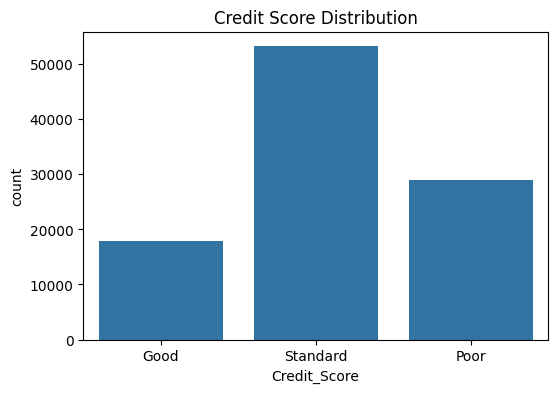

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(6,4))
sns.countplot(data=train, x='Credit_Score')
plt.title('Credit Score Distribution')
plt.show()


#Credit_Score의 분포를 확인한 결과, Standard 등급이 가장 많고 Good 등급이 가장 적었다. 따라서 클래스가 완전히 균등하지 않으며,
#모델 학습 시 Standard 클래스를 더 잘 맞히는 방향으로 편향될 가능성이 있다. 그러므로 단순 정확도뿐 아니라 각 클래스별 예측 성능도 함께 확인할 필요가 있다.


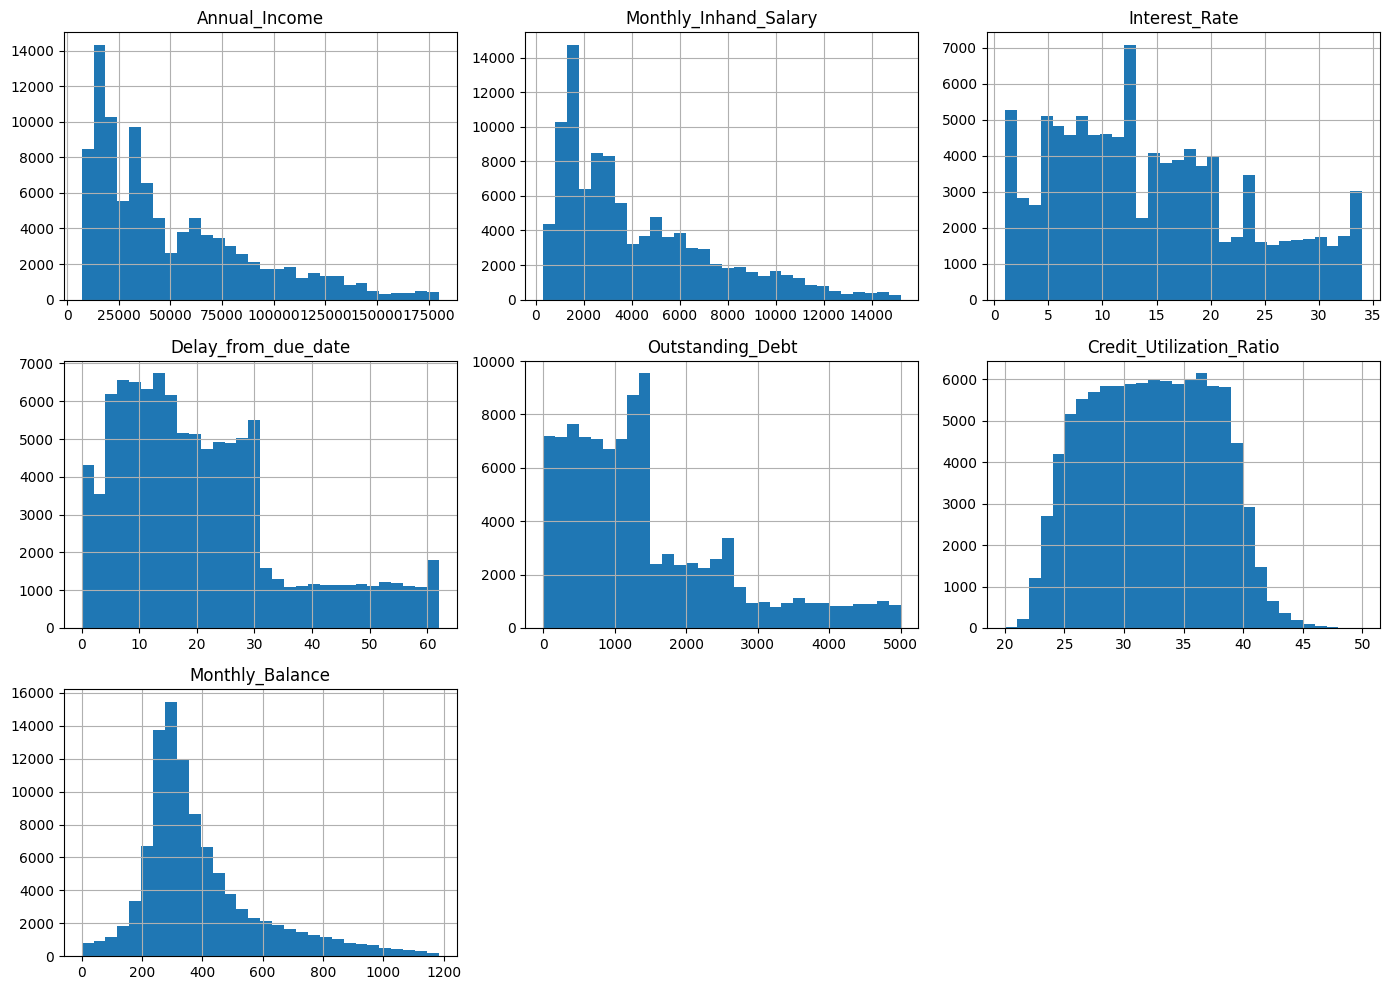

In [85]:
important_numeric = [
    'Annual_Income',
    'Monthly_Inhand_Salary',
    'Interest_Rate',
    'Delay_from_due_date',
    'Outstanding_Debt',
    'Credit_Utilization_Ratio',
    'Monthly_Balance'
]

train[important_numeric].hist(figsize=(14, 10), bins=30, grid=True)
plt.tight_layout()
plt.show()


# 주요 수치형 변수들의 분포를 확인한 결과, Annual_Income, Monthly_Inhand_Salary, Delay_from_due_date, Outstanding_Debt는 낮은 값 구간에 데이터가 많이 몰리고 값이 커질수록 빈도가 감소하는 경향을 보였다.
# Monthly_Balance는 200~400 구간에 집중되었으며 일부 큰 값이 존재했고, Credit_Utilization_Ratio는 25~40 구간에 비교적 집중되어 있었다.
# 변수마다 단위와 값의 범위가 다르기 때문에 모델 학습 전 StandardScaler를 이용한 표준화가 필요하다고 판단하였다.



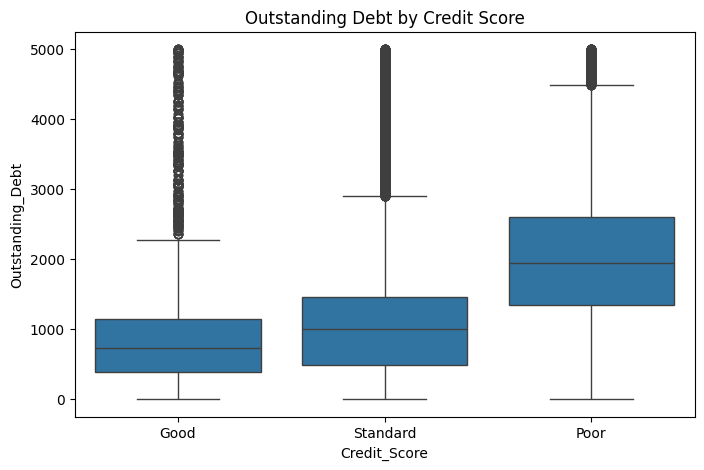

In [86]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='Credit_Score', y='Outstanding_Debt')
plt.title('Outstanding Debt by Credit Score')
plt.show()

# OutStanding Debt는 고객이 아직 같지 않은 미지급 잔액, 즉 미상환 부채를 말한다.
# Outstanding_Debt는 Credit_Score 등급에 따라 뚜렷한 차이를 보였다.
# Good 등급은 부채가 낮고, Poor 등급은 부채가 높게 분포하여 미상환 부채가 신용점수 분류에 중요한 영향을 줄 수 있음을 확인하였다.


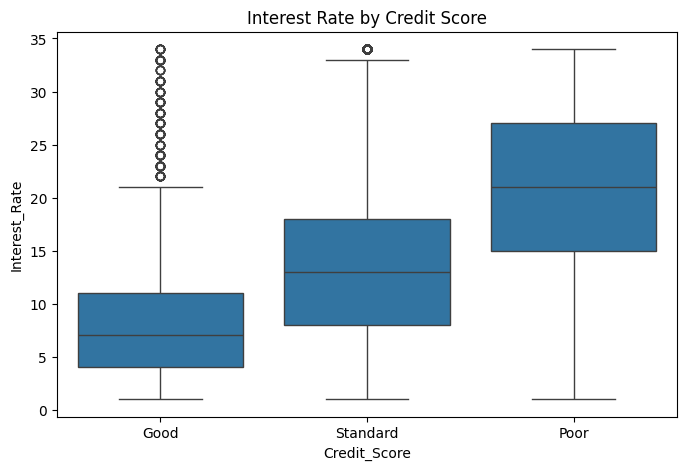

In [87]:
plt.figure(figsize=(8,5))
sns.boxplot(data=train, x='Credit_Score', y='Interest_Rate')
plt.title('Interest Rate by Credit Score')
plt.show()

# Interest_Rate는 고객에게 적용된 신용카드 이자율을 의미한다.
# Interest_Rate는 Credit_Score 등급에 따라 뚜렷한 차이를 보였다.
# Good 등급은 낮은 이자율에, Poor 등급은 높은 이자율에 분포하는 경향이 있다.
# 즉 이자율이 높을수록 신용점수가 낮은 등급(Poor)에 가까워지는 경향이 확인할 수 있다



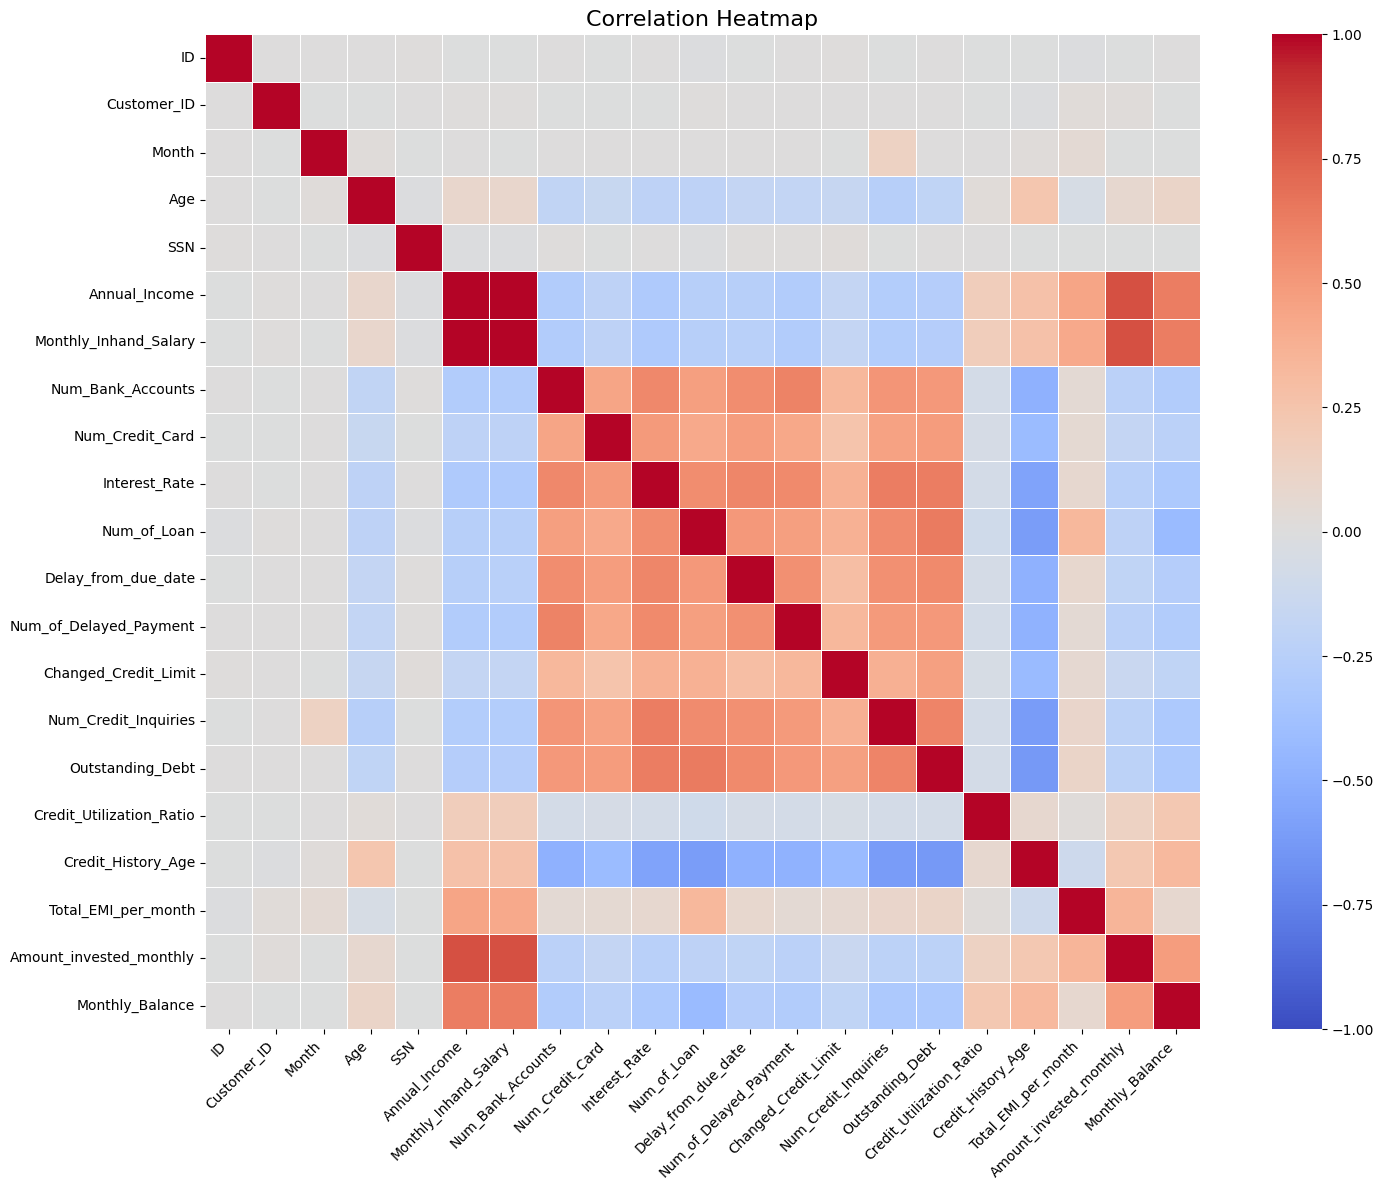

In [88]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    train[numeric_cols].corr(),
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    linecolor='white',
    square=True
)

plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



# 상관관계 히트맵을 통해 수치형 변수들 간의 관계를 확인하였다.
# Annual_Income과 Monthly_Inhand_Salary는 강한 양의 상관관계를 보여 소득 관련 정보가 서로 밀접하게 연관되어 있음을 확인하였다.
# Interest_Rate, Num_of_Loan, Delay_from_due_date, Num_of_Delayed_Payment, Outstanding_Debt는 서로 양의 상관관계를 보여
# 대출 규모, 연체 횟수, 미지급 잔액 등이 함께 증가하는 경향을 나타냈다.
# 반면 Credit_History_Age는 이러한 위험 변수들과 음의 상관관계를 보여
# 신용 이력이 길수록 연체 및 미상환 부채 관련 위험이 낮아지는 경향을 확인할 수 있었다.
# 이를 바탕으로 ID, Customer_ID, SSN과 같은 식별자 컬럼은 제거하고,
# 금융 행동 및 신용 상태를 반영하는 변수들을 모델 학습에 활용하였다.

In [92]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

file_path = 'train2.csv'
data = pd.read_csv(file_path)



# 전처리 아이디어 및 논리
# 전체 결측치 개수를 확인한 결과 결측치가 0개였으므로 별도의 대체나 삭제는 수행하지 않았다.
# ID, Customer_ID, Name, SSN은 개인 식별자 성격이 강해 일반적인 신용점수 패턴 학습에 부적절하다고 판단하여 제거하였다.
# 범주형 변수는 문자열 형태라 MLP 모델에 직접 입력할 수 없으므로 LabelEncoder로 숫자형으로 변환하였다.
# 이후 train/test를 분리하고, 데이터 누수를 막기 위해 scaler는 train 데이터에만 fit한 뒤 test에는 transform만 적용하였다.

# Feature Selection 및 모델 선택
# Occupation, Type_of_Loan, Credit_Mix, Payment_of_Min_Amount, Payment_Behaviour는 고객의 직업, 대출 유형, 신용 상태, 결제 행동을 반영하므로 인코딩 후 사용하였다.
# 본 문제는 Good, Standard, Poor 세 클래스를 예측하는 다중분류 문제이므로 CrossEntropyLoss를 사용하는 MLP 모델을 선택하였다.




data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

for col in categorical_columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

X = data.drop('Credit_Score', axis=1).values
y = data['Credit_Score'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


class CreditScoreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = CreditScoreDataset(X_train, y_train)
test_dataset = CreditScoreDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 3)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


input_size = X_train.shape[1]
model = MLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 20

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


print(f'Final Validation Accuracy: {val_accuracy:.2f}%')





Epoch [1/20], Loss: 0.6897, 학습 정확도: 68.31%, 평가 정확도: 69.30%
Epoch [2/20], Loss: 0.6523, 학습 정확도: 70.35%, 평가 정확도: 70.11%
Epoch [3/20], Loss: 0.6425, 학습 정확도: 70.60%, 평가 정확도: 69.78%
Epoch [4/20], Loss: 0.6368, 학습 정확도: 70.85%, 평가 정확도: 70.42%
Epoch [5/20], Loss: 0.6320, 학습 정확도: 70.98%, 평가 정확도: 70.77%
Epoch [6/20], Loss: 0.6279, 학습 정확도: 71.15%, 평가 정확도: 71.02%
Epoch [7/20], Loss: 0.6243, 학습 정확도: 71.37%, 평가 정확도: 70.80%
Epoch [8/20], Loss: 0.6215, 학습 정확도: 71.54%, 평가 정확도: 70.57%
Epoch [9/20], Loss: 0.6191, 학습 정확도: 71.68%, 평가 정확도: 71.08%
Epoch [10/20], Loss: 0.6162, 학습 정확도: 71.83%, 평가 정확도: 71.09%
Epoch [11/20], Loss: 0.6136, 학습 정확도: 71.94%, 평가 정확도: 71.16%
Epoch [12/20], Loss: 0.6118, 학습 정확도: 71.94%, 평가 정확도: 71.00%
Epoch [13/20], Loss: 0.6095, 학습 정확도: 72.17%, 평가 정확도: 71.20%
Epoch [14/20], Loss: 0.6076, 학습 정확도: 72.33%, 평가 정확도: 71.31%
Epoch [15/20], Loss: 0.6056, 학습 정확도: 72.26%, 평가 정확도: 71.50%
Epoch [16/20], Loss: 0.6037, 학습 정확도: 72.54%, 평가 정확도: 71.18%
Epoch [17/20], Loss: 0.6017, 학습 정확도: 72.55%, 평가 정

In [90]:
# 개선사항
# 기존 64-32 구조의 MLP는 validation accuracy가 70% 초반에 머물러 모델 표현력이 부족하다고 판단하였다.
# 따라서 기존 코드는 유지한 채 256-128-64 구조의 개선 모델을 추가하였다.
# BatchNorm1d는 각 층의 입력 분포를 안정화하여 학습을 원활하게 하기 위해 사용하였다.
# Dropout과 weight_decay는 특정 노드나 가중치에 과도하게 의존하는 것을 줄여 과적합을 완화하기 위해 적용하였다.
# 또한 batch_size를 128, epoch를 50으로 조정하여 더 충분하고 안정적인 학습이 가능하도록 개선하였다.



class ImprovedMLP(nn.Module):
    def __init__(self, input_size):
        super(ImprovedMLP, self).__init__()

        self.layer1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(0.2)

        self.layer2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.2)

        self.layer3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(0.2)

        self.output_layer = nn.Linear(64, 3)

    def forward(self, x):
        x = torch.relu(self.bn1(self.layer1(x)))
        x = self.dropout1(x)

        x = torch.relu(self.bn2(self.layer2(x)))
        x = self.dropout2(x)

        x = torch.relu(self.bn3(self.layer3(x)))
        x = self.dropout3(x)

        x = self.output_layer(x)
        return x
improved_train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
improved_test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

improved_model = ImprovedMLP(input_size).to(device)

criterion = nn.CrossEntropyLoss()
improved_optimizer = optim.Adam(
    improved_model.parameters(),
    lr=0.001,
    weight_decay=1e-5
)

improved_epochs = 50
best_val_accuracy = 0

for epoch in range(improved_epochs):
    improved_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in improved_train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        improved_optimizer.zero_grad()
        outputs = improved_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        improved_optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    improved_model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in improved_test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = improved_model(inputs)

            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    best_val_accuracy = max(best_val_accuracy, val_accuracy)

    print(f'Epoch [{epoch+1}/{improved_epochs}], Loss: {running_loss/len(improved_train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')

print(f'Best Validation Accuracy: {best_val_accuracy:.2f}%')


Epoch [1/50], Loss: 0.7025, 학습 정확도: 67.93%, 평가 정확도: 70.20%
Epoch [2/50], Loss: 0.6652, 학습 정확도: 69.60%, 평가 정확도: 70.43%
Epoch [3/50], Loss: 0.6555, 학습 정확도: 70.09%, 평가 정확도: 70.66%
Epoch [4/50], Loss: 0.6501, 학습 정확도: 70.31%, 평가 정확도: 70.75%
Epoch [5/50], Loss: 0.6445, 학습 정확도: 70.48%, 평가 정확도: 70.92%
Epoch [6/50], Loss: 0.6418, 학습 정확도: 70.77%, 평가 정확도: 71.11%
Epoch [7/50], Loss: 0.6384, 학습 정확도: 70.85%, 평가 정확도: 71.14%
Epoch [8/50], Loss: 0.6352, 학습 정확도: 70.99%, 평가 정확도: 71.26%
Epoch [9/50], Loss: 0.6309, 학습 정확도: 71.17%, 평가 정확도: 71.42%
Epoch [10/50], Loss: 0.6298, 학습 정확도: 71.25%, 평가 정확도: 71.47%
Epoch [11/50], Loss: 0.6274, 학습 정확도: 71.34%, 평가 정확도: 71.53%
Epoch [12/50], Loss: 0.6246, 학습 정확도: 71.40%, 평가 정확도: 71.61%
Epoch [13/50], Loss: 0.6246, 학습 정확도: 71.47%, 평가 정확도: 71.61%
Epoch [14/50], Loss: 0.6211, 학습 정확도: 71.58%, 평가 정확도: 71.69%
Epoch [15/50], Loss: 0.6182, 학습 정확도: 71.79%, 평가 정확도: 71.63%
Epoch [16/50], Loss: 0.6150, 학습 정확도: 71.70%, 평가 정확도: 71.77%
Epoch [17/50], Loss: 0.6161, 학습 정확도: 71.93%, 평가 정

In [91]:
# 50 epoch 학습 후 74%대까지 향상되었고, 이후 learning rate를 0.0005로 낮춰 추가 학습을 진행한다.

for param_group in improved_optimizer.param_groups:
    param_group['lr'] = 0.0005

additional_epochs = 5

for epoch in range(additional_epochs):
    improved_model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in improved_train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        improved_optimizer.zero_grad()
        outputs = improved_model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        improved_optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += (predicted == targets).sum().item()

    improved_model.eval()
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for inputs, targets in improved_test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = improved_model(inputs)

            _, predicted = torch.max(outputs, 1)
            total_val += targets.size(0)
            correct_val += (predicted == targets).sum().item()

    train_accuracy = 100 * correct_train / total_train
    val_accuracy = 100 * correct_val / total_val
    best_val_accuracy = max(best_val_accuracy, val_accuracy)

    print(f'Additional Epoch [{epoch+1}/{additional_epochs}], Loss: {running_loss/len(improved_train_loader):.4f}, '
          f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')

print(f'Best Validation Accuracy: {best_val_accuracy:.2f}%')


# 기본 모델 Final Validation Accuracy: 71.70%
# 개선 모델 50 epoch Best Validation Accuracy: 74.65%
# 추가 학습 후 Best Validation Accuracy: 75.42%



# validation score 출력 및 추가 학습
# 개선 모델을 50 epoch 학습한 결과 74.65%까지 상승했지만 권장 기준인 75%에는 도달하지 못하였다.
# 학습 정확도와 평가 정확도가 비슷하고 계속 상승하는 흐름을 보여 과적합보다 추가 학습 여지가 있다고 판단하였다.
# 따라서 learning rate를 0.001에서 0.0005로 낮추고 5 epoch 추가 학습을 진행하였다.


# 최종적으로 정리하면, 50 epoch 학습 후 74%대까지 향상되었고, 이후 learning rate를 0.0005로 낮춰 5 epoch 추가 학습한 결과 75.42%까지 개선되었다.

Additional Epoch [1/5], Loss: 0.5566, 학습 정확도: 74.59%, 평가 정확도: 74.83%
Additional Epoch [2/5], Loss: 0.5552, 학습 정확도: 74.67%, 평가 정확도: 75.19%
Additional Epoch [3/5], Loss: 0.5522, 학습 정확도: 74.80%, 평가 정확도: 75.42%
Additional Epoch [4/5], Loss: 0.5507, 학습 정확도: 75.07%, 평가 정확도: 75.20%
Additional Epoch [5/5], Loss: 0.5498, 학습 정확도: 74.96%, 평가 정확도: 75.25%
Best Validation Accuracy: 75.42%
